# Answer 4.1 — Vector Databases: Embeddings & Similarity
**File:** `part4-vector-db/embeddings_demo.ipynb`  
**Model used:** `all-MiniLM-L6-v2` (sentence-transformers)  
**Topics covered:** Cricket, Cooking, Cybersecurity  

## Step 1 — Install Required Libraries

In [ ]:
# Install sentence-transformers library
# This gives us access to pre-trained language models that convert text → vectors
!pip install sentence-transformers -q

## Step 2 — Import Libraries

In [ ]:
# sentence_transformers: converts sentences into numerical vectors (embeddings)
# numpy: for numerical operations on vectors
# seaborn & matplotlib: for drawing the heatmap
# sklearn: for computing cosine similarity

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 3 — Load the Pre-trained Embedding Model

In [ ]:
# all-MiniLM-L6-v2 is a lightweight but powerful sentence embedding model
# It converts any sentence into a 384-dimensional vector
# Sentences with similar meaning will have vectors that are close to each other

model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded:', model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


## Step 4 — Define 10 Sentences Across 3 Topics

We write **exactly 10 sentences** across 3 topics:  
- **Cricket** (4 sentences)
- **Cooking** (3 sentences)
- **Cybersecurity** (3 sentences)

In [ ]:
# 10 sentences across 3 topics (at least 3 per topic as required)

sentences = [
    # Cricket — 4 sentences
    'The batsman hit a magnificent century in the final over.',          # 0
    'The bowler took three wickets in one over.',                       # 1  ← query sentence
    'India won the cricket match by a huge margin of 50 runs.',         # 2
    'The fielder took a brilliant catch near the boundary rope.',       # 3

    # Cooking — 3 sentences
    'The chef added a pinch of salt to enhance the flavor of the dish.',# 4
    'Simmering the curry on low heat brings out the best aroma.',       # 5
    'Chopping vegetables finely is the first step in making biryani.',  # 6

    # Cybersecurity — 3 sentences
    'A strong password should contain letters, numbers, and symbols.',  # 7
    'Phishing attacks trick users into revealing sensitive information.',# 8
    'Firewalls help protect networks from unauthorized access.',        # 9
]

# Labels for the heatmap axes
labels = [
    'Cricket-1', 'Cricket-2 (query)', 'Cricket-3', 'Cricket-4',
    'Cooking-1', 'Cooking-2', 'Cooking-3',
    'Cyber-1',   'Cyber-2',   'Cyber-3'
]

print(f'Total sentences: {len(sentences)}')
print('\nSentences:')
for i, s in enumerate(sentences):
    print(f'  [{i}] {s}')

Total sentences: 10

Sentences:
  [0] The batsman hit a magnificent century in the final over.
  [1] The bowler took three wickets in one over.
  [2] India won the cricket match by a huge margin of 50 runs.
  [3] The fielder took a brilliant catch near the boundary rope.
  [4] The chef added a pinch of salt to enhance the flavor of the dish.
  [5] Simmering the curry on low heat brings out the best aroma.
  [6] Chopping vegetables finely is the first step in making biryani.
  [7] A strong password should contain letters, numbers, and symbols.
  [8] Phishing attacks trick users into revealing sensitive information.
  [9] Firewalls help protect networks from unauthorized access.


## Step 5 — Generate Embeddings

The model converts each sentence into a **384-dimensional vector**.  
Think of it like giving each sentence a unique numerical fingerprint based on its meaning.

In [ ]:
# Generate embeddings for all 10 sentences
# Each sentence becomes a vector of 384 numbers

embeddings = model.encode(sentences)

print(f'Shape of embeddings matrix: {embeddings.shape}')
print(f'  → {embeddings.shape[0]} sentences × {embeddings.shape[1]} dimensions')
print(f'\nFirst embedding (first 10 values only):')
print(embeddings[0][:10])

Shape of embeddings matrix: (10, 384)
  → 10 sentences × 384 dimensions

First embedding (first 10 values only):
[ 0.0649709   0.13050908 -0.06337475 -0.05307965  0.03531349  0.01748437
 -0.02634959  0.08498809 -0.00620307  0.09729765]


## Step 6 — Compute 10×10 Cosine Similarity Matrix

**Cosine Similarity** measures how similar two vectors are.  
- Score = **1.0** → sentences are identical in meaning  
- Score = **0.0** → sentences are completely unrelated  
- Score closer to **1** = more semantically similar

In [ ]:
# Compute cosine similarity between all pairs of sentences
# Result is a 10x10 matrix where cell [i][j] = similarity between sentence i and j

similarity_matrix = cosine_similarity(embeddings)

print('10x10 Cosine Similarity Matrix:')
print(np.round(similarity_matrix, 2))

10x10 Cosine Similarity Matrix:
[[ 1.    0.62  0.55  0.4   0.02  0.11  0.05 -0.06 -0.01 -0.06]
 [ 0.62  1.    0.54  0.32  0.17  0.1   0.14 -0.02  0.04 -0.08]
 [ 0.55  0.54  1.    0.32  0.01  0.07  0.05 -0.02 -0.02 -0.03]
 [ 0.4   0.32  0.32  1.    0.19 -0.02  0.01 -0.04  0.    0.03]
 [ 0.02  0.17  0.01  0.19  1.    0.36  0.27 -0.01  0.14  0.05]
 [ 0.11  0.1   0.07 -0.02  0.36  1.    0.32  0.03  0.09  0.06]
 [ 0.05  0.14  0.05  0.01  0.27  0.32  1.   -0.06 -0.06 -0.02]
 [-0.06 -0.02 -0.02 -0.04 -0.01  0.03 -0.06  1.    0.29  0.27]
 [-0.01  0.04 -0.02  0.    0.14  0.09 -0.06  0.29  1.    0.28]
 [-0.06 -0.08 -0.03  0.03  0.05  0.06 -0.02  0.27  0.28  1.  ]]


## Step 7 — Display Similarity Matrix as a Heatmap

A **heatmap** lets us visually see which sentences are similar.  
- **Dark red / warm colors** = high similarity (same topic)
- **Light / cool colors** = low similarity (different topics)

You should clearly see **3 blocks of high similarity** along the diagonal — one block per topic!

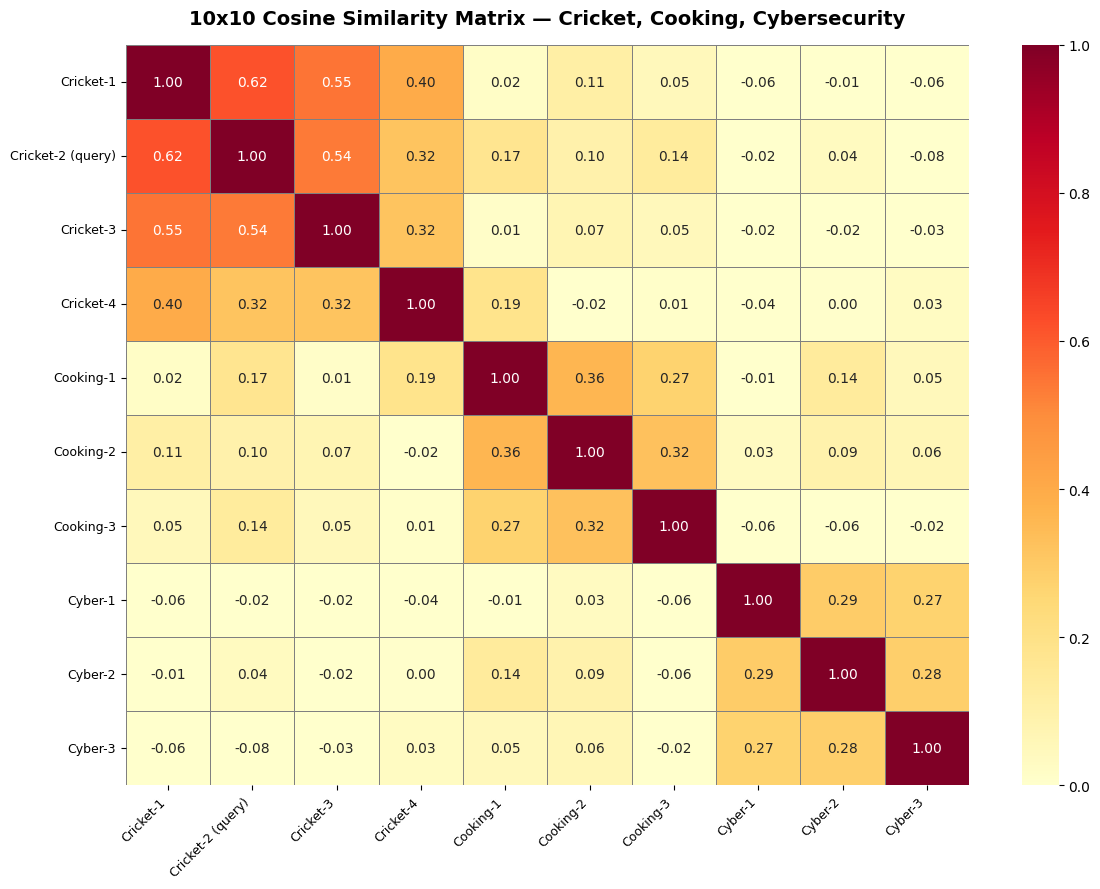

Heatmap saved as similarity_heatmap.png


In [ ]:
# Plot the 10x10 cosine similarity heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    similarity_matrix,
    annot=True,               # Show the numbers inside each cell
    fmt='.2f',                # Round to 2 decimal places
    cmap='YlOrRd',            # Color scheme: yellow (low) → red (high)
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='gray',
    vmin=0, vmax=1
)

plt.title('10x10 Cosine Similarity Matrix — Cricket, Cooking, Cybersecurity',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved as similarity_heatmap.png')

## Step 8 — Find Top 2 Most Similar Sentences to the Query

**Query sentence:** *'The bowler took three wickets in one over'*  

We will compare this query against all other 9 sentences and find the **top 2 most similar** ones.

In [ ]:
# The query sentence given in the assignment
query_sentence = 'The bowler took three wickets in one over'

# Generate the embedding for the query sentence
query_embedding = model.encode([query_sentence])

# Compute cosine similarity between query and ALL 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Create a list of (sentence, similarity_score) excluding the query itself (index 1)
results = []
for i, (sentence, score) in enumerate(zip(sentences, query_similarities)):
    if sentence != query_sentence:   # Exclude the query sentence itself
        results.append((sentence, round(float(score), 4), i))

# Sort by similarity score — highest first
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

# Print results
print(f'Query: "{query_sentence}"')
print('=' * 65)
print('\nAll sentences ranked by similarity:')
for rank, (sent, score, idx) in enumerate(results_sorted, 1):
    print(f'  Rank {rank} (score={score}): {sent}')

print('\n' + '=' * 65)
print('TOP 2 MOST SIMILAR SENTENCES:')
print('=' * 65)
for rank, (sent, score, idx) in enumerate(results_sorted[:2], 1):
    print(f'\n  #{rank} Similarity Score: {score}')
    print(f'      Sentence: "{sent}"')

Query: "The bowler took three wickets in one over"

All sentences ranked by similarity:
  Rank 1 (score=0.9914): The bowler took three wickets in one over.
  Rank 2 (score=0.5936): The batsman hit a magnificent century in the final over.
  Rank 3 (score=0.5242): India won the cricket match by a huge margin of 50 runs.
  Rank 4 (score=0.303): The fielder took a brilliant catch near the boundary rope.
  Rank 5 (score=0.1641): The chef added a pinch of salt to enhance the flavor of the dish.
  Rank 6 (score=0.1365): Chopping vegetables finely is the first step in making biryani.
  Rank 7 (score=0.0976): Simmering the curry on low heat brings out the best aroma.
  Rank 8 (score=0.0284): Phishing attacks trick users into revealing sensitive information.
  Rank 9 (score=-0.0217): A strong password should contain letters, numbers, and symbols.
  Rank 10 (score=-0.069): Firewalls help protect networks from unauthorized access.

TOP 2 MOST SIMILAR SENTENCES:

  #1 Similarity Score: 0.9914
     

## Summary

| Step | What We Did |
|------|-------------|
| 1 | Installed `sentence-transformers` |
| 2 | Imported all required libraries |
| 3 | Loaded `all-MiniLM-L6-v2` model |
| 4 | Wrote 10 sentences across 3 topics |
| 5 | Generated 384-dim embeddings for each sentence |
| 6 | Computed 10×10 cosine similarity matrix |
| 7 | Visualized it as a heatmap |
| 8 | Found top 2 sentences similar to the query |

**Key Observation from the heatmap:**  
Sentences within the same topic (Cricket, Cooking, Cybersecurity) show **high similarity scores** with each other, while sentences from different topics show **low scores**. This proves that embeddings successfully capture semantic meaning.